# XAI CODE DEMO

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/dev/interpretable-ml-example-notebooks/generalized-models-interpretability.ipynb)

# Generalized Models

* Generalized Linear Models (GLMs)
* Generalized Additive Models (GAMs)

In [1]:
!pip install pygam --quiet


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Gamma
from statsmodels.genmod.families.links import Log
from statsmodels.tools import add_constant

# from pygam import LinearGAM, GammaGAM, s
from pygam import LogisticGAM, s, f
import seaborn as sns

## 1. Dataset loading and cleaning

#### Dataset

We will be using the [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code)

In [3]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path, "\n")

# Read the CSV
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

# Preview
display(df.head())

/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 172k/172k [00:00<00:00, 2.00MB/s]

Extracting files...
Path to dataset files: /Users/tonantzinrealrojas/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1 



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
for column in df.columns:
    print(f"Column: {column} ({df[column].nunique()})")
    print(df[column].unique())
    print("\n")

Column: customerID (7043)
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']


Column: gender (2)
['Female' 'Male']


Column: SeniorCitizen (2)
[0 1]


Column: Partner (2)
['Yes' 'No']


Column: Dependents (2)
['No' 'Yes']


Column: tenure (73)
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


Column: PhoneService (2)
['No' 'Yes']


Column: MultipleLines (3)
['No phone service' 'No' 'Yes']


Column: InternetService (3)
['DSL' 'Fiber optic' 'No']


Column: OnlineSecurity (3)
['No' 'Yes' 'No internet service']


Column: OnlineBackup (3)
['Yes' 'No' 'No internet service']


Column: DeviceProtection (3)
['No' 'Yes' 'No internet service']


Column: TechSupport (3)
['No' 'Yes' 'No internet service']


Column: StreamingTV (3)
['No' 'Yes' 'No internet service']


Column: StreamingMovies 

Convert to numeric

In [6]:
for feat in ["MonthlyCharges", "TotalCharges"]:
    # Convert the feature to numeric, handling potential non-numeric entries (empty strings) as NaN.
    df[feat] = pd.to_numeric(df[feat], errors="coerce")

    # Fill any NaN values that resulted from the conversion (e.g., empty strings) with 0.
    df[feat] = df[feat].fillna(0)

Convert to binary

In [7]:
# Convert feat to object type to treat it as a categorical feature.
for feat in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]:
    df[feat] = df[feat].map({"Yes": 1, "No": 0})

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


## 2. EDA relevant to GAM assumptions

In [9]:
# 1. Class Distribution
print("Target Distribution:")
print(df["Churn"].value_counts(normalize=True))

Target Distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


The dataset has moderate class imbalance, so accuracy alone is misleading; model evaluation must rely on metrics like ROC-AUC, Precision-Recall, and F1-score.

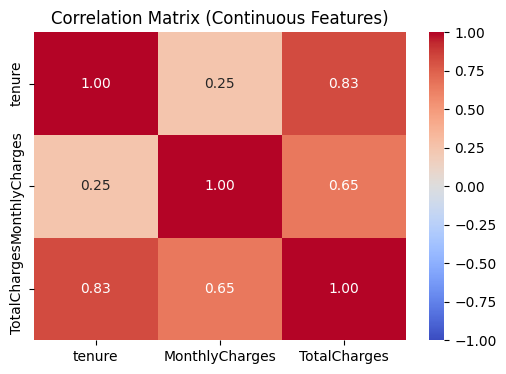

In [10]:
# 2. Multicollinearity: Correlation Matrix for Continuous Features
continuous_feats = ["tenure", "MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[continuous_feats].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1
)
plt.title("Correlation Matrix (Continuous Features)")
plt.show()

TotalCharges is highly correlated with tenure ($r = 0.83$) and MonthlyCharges ($r = 0.65$). TotalCharges is could be a mathematical byproduct ($\approx \text{tenure} \times \text{MonthlyCharges}$). I'll still keep all of them

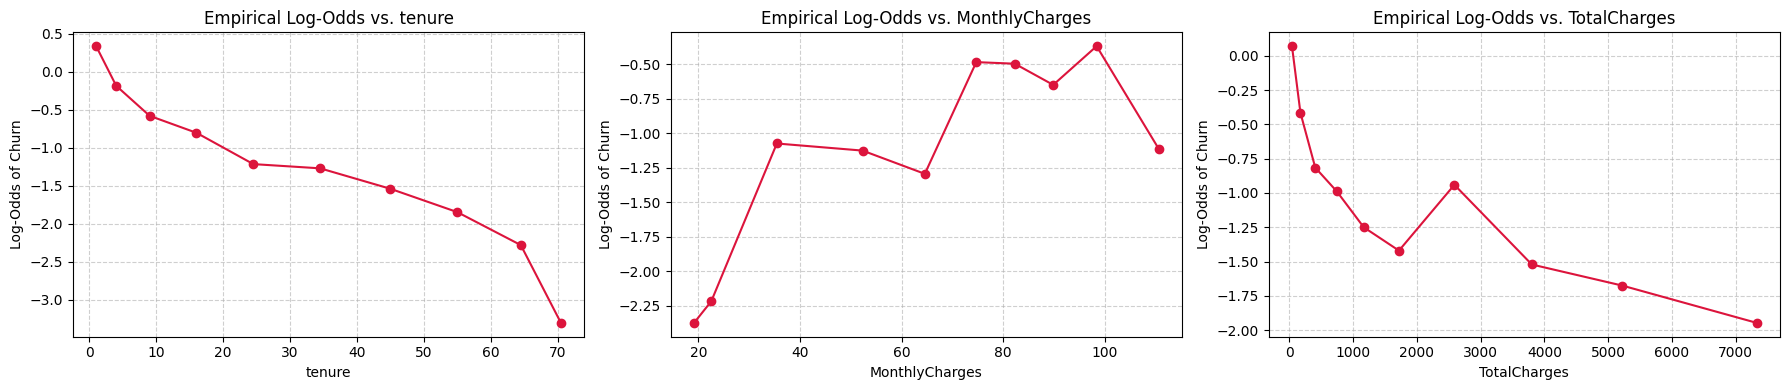

In [11]:
# 3. Non-Linearity on the Log-Odds Scale (Empirical Logit vs. Continuous Features)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(continuous_feats):
    # Create 10 quantile bins
    binned = pd.qcut(df[col], q=10, duplicates="drop")
    bin_stats = (
        df.groupby(binned, observed=True)["Churn"].agg(["count", "mean"]).reset_index()
    )

    # Calculate empirical logit: log(p / (1 - p))
    # Add a small epsilon to prevent division by zero or log(0)
    eps = 1e-4
    p = bin_stats["mean"].clip(eps, 1 - eps)
    bin_stats["log_odds"] = np.log(p / (1 - p))

    # Use midpoint of intervals for x-axis
    bin_stats["midpoint"] = bin_stats[col].apply(lambda x: x.mid)

    axes[i].plot(
        bin_stats["midpoint"], bin_stats["log_odds"], marker="o", color="crimson"
    )
    axes[i].set_title(f"Empirical Log-Odds vs. {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Log-Odds of Churn")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**tenure (Non-linear):** Churn drops steeply in the first few months and flattens out, showing that early customers have the highest risk.

**MonthlyCharges (Non-monotonic):** Churn risk starts very low for cheap plans, rises sharply in the mid-tiers, and peaks near $90 before dipping, showing price-tier sensitivity.

**TotalCharges (Non-linear):** Churn drops rapidly at low amounts and levels off, reflecting high early dropouts and diminishing impact as total spend grows.

## 3. GAM code

## Generalized Additive Model (GAM)

* GAMs assume that the outcome can be modeled by a sum of arbitrary functions of each feature
* GAMs use B splines, which allow us to automatically model non-linear relationships
* GAM is still a sum of feature effects, but it gives the option to allow nonlinear relationships between some features and the output

#### Terminology
* LinearGAM: uses a Normal (Gaussian) error distribution
* s(*i*): Represents a spline term for the *i*th feature, allowing for flexible, non-linear relationships between the feature and the response variable

We are using the pygam library. Documentation [here](https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html).

* The gridsearch method performs a grid search over a pre-defined range of hyperparameters to find the best set of hyperparameters (smoothing parameters for each spline term). The method evaluates different combinations of hyperparameters using cross-validation on the training data and selects the combination that minimizes the cross-validation error.

In [12]:
df_model = df.drop(columns=["customerID", "CustomerID"], errors="ignore").copy()

In [13]:
num_feats = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_feats = [
    "gender",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]
bin_feats = [
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
]

In [14]:
# Convert categoricals to integer codes for pygam's f() terms
for col in cat_feats:
    df_model[col] = df_model[col].astype("category").cat.codes

In [15]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int8   
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int8   
 7   InternetService   7043 non-null   int8   
 8   OnlineSecurity    7043 non-null   int8   
 9   OnlineBackup      7043 non-null   int8   
 10  DeviceProtection  7043 non-null   int8   
 11  TechSupport       7043 non-null   int8   
 12  StreamingTV       7043 non-null   int8   
 13  StreamingMovies   7043 non-null   int8   
 14  Contract          7043 non-null   int8   
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int8   


In [16]:
feats = num_feats + cat_feats + bin_feats
print(len(feats))

19


In [17]:
X = df_model[feats].values
y = df_model["Churn"].values

In [18]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (5634, 19), X_test shape: (1409, 19)


In [19]:
# Build formula:
# Index 0 (tenure) -> s(0)
# Index 1 (MonthlyCharges) -> s(1)
# Indices 2 to 17 -> f(i) for each categorical feature
formula = s(0, n_splines=15) + s(1, n_splines=15) + s(2, n_splines=15)
for i in range(len(num_feats), len(feats)):
    formula += f(i)

gam = LogisticGAM(formula)

In [20]:
# Run gridsearch across a range of smoothing parameters (lam)
lam = np.logspace(-2, 3, 11)
print("Running Gridsearch for LogisticGAM...")
gam.gridsearch(X_train, y_train, lam=lam)

# Display model summary
gam.summary()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:802: RuntimeWarning: divide by zero encountered in dot
  B = (Vt.T * d_inv).dot(U1.T).dot(Q.T)
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:802: RuntimeWarning: overflow encountered in dot
  B = (Vt.T * d_inv).dot(U1.T).dot(Q.T)
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:802: RuntimeWarning: invalid value encountered in dot
  B = (Vt.T * d_inv).dot(U1.T).dot(Q.T)
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:803: RuntimeWarning: divide by zero encountered in dot
  coef_new = B.dot(pseudo_data).flatten()
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:803: RuntimeWarning: overflow encountered in dot
  coef_new = B.dot(pseudo_data).flatten()
/Users/tonantzinrealrojas/miniforge3/lib/python3.

Running Gridsearch for LogisticGAM...


/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:802: RuntimeWarning: divide by zero encountered in dot
  B = (Vt.T * d_inv).dot(U1.T).dot(Q.T)
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:802: RuntimeWarning: overflow encountered in dot
  B = (Vt.T * d_inv).dot(U1.T).dot(Q.T)
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:802: RuntimeWarning: invalid value encountered in dot
  B = (Vt.T * d_inv).dot(U1.T).dot(Q.T)
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:803: RuntimeWarning: divide by zero encountered in dot
  coef_new = B.dot(pseudo_data).flatten()
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:803: RuntimeWarning: overflow encountered in dot
  coef_new = B.dot(pseudo_data).flatten()
/Users/tonantzinrealrojas/miniforge3/lib/python3.12/site-packages/pygam/pygam.py:803: RuntimeWarning: invalid value encountered i

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     49.6244
Link Function:                        LogitLink Log Likelihood:                                 -2259.5862
Number of Samples:                         5634 AIC:                                             4618.4213
                                                AICc:                                            4619.3576
                                                UBRE:                                               2.8268
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3068
Feature Function                  Lam

/var/folders/5m/q3t_7tx11l750b5hqf72gt3r0000gn/T/ipykernel_29725/1552381764.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


**Significance of Smooth Terms:** All three spline features (tenure, MonthlyCharges, TotalCharges) are statistically significant ($p < 0.01$), confirming their non-linear contributions to churn risk.

## 4. Model performance evidence

Test Set Performance Metrics:
  ROC-AUC Score : 0.8476
  Accuracy      : 0.8027
  Precision     : 0.6558
  Recall        : 0.5401
  F1-Score      : 0.5924

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



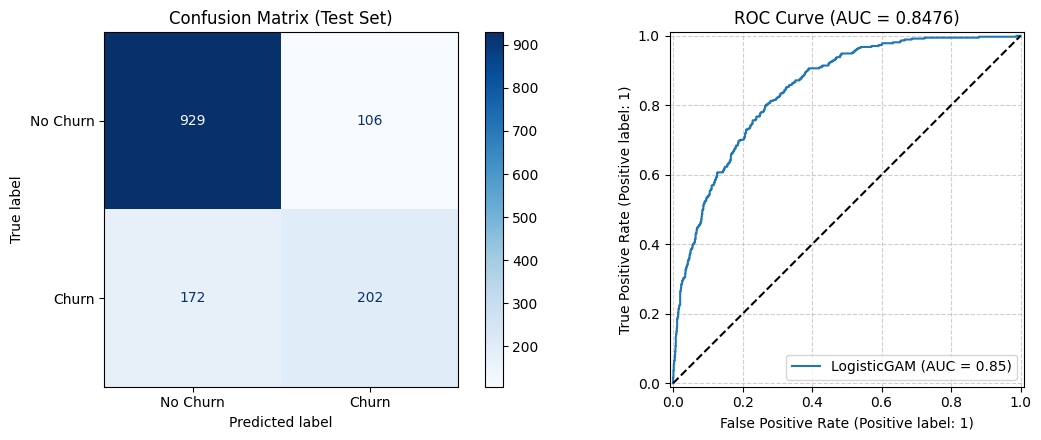

In [21]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# 1. Generate probabilities and class predictions on the test set
y_prob = gam.predict_proba(X_test)
y_pred = gam.predict(X_test)

# 2. Compute key classification metrics
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Test Set Performance Metrics:")
print(f"  ROC-AUC Score : {auc:.4f}")
print(f"  Accuracy      : {acc:.4f}")
print(f"  Precision     : {prec:.4f}")
print(f"  Recall        : {rec:.4f}")
print(f"  F1-Score      : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# 3. Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Churn", "Churn"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion Matrix (Test Set)")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="LogisticGAM")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Chance")
axes[1].set_title(f"ROC Curve (AUC = {auc:.4f})")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**Discriminative Power:** An ROC-AUC of 0.8476 shows strong capability in ranking high-risk churners above retained customers.

**Accuracy vs. Class Imbalance:** Overall accuracy is 80.27%, outperforming the 73.5% majority-class baseline.

**Precision-Recall Trade-off:** At the default 0.5 threshold, the model achieves 65.58% precision and 54.01% recall (F1 = 0.5924), capturing the majority of churners while keeping false alarms relatively low (106 false positives vs. 929 true negatives).

## 5. Smooth effect interpretation in markdown

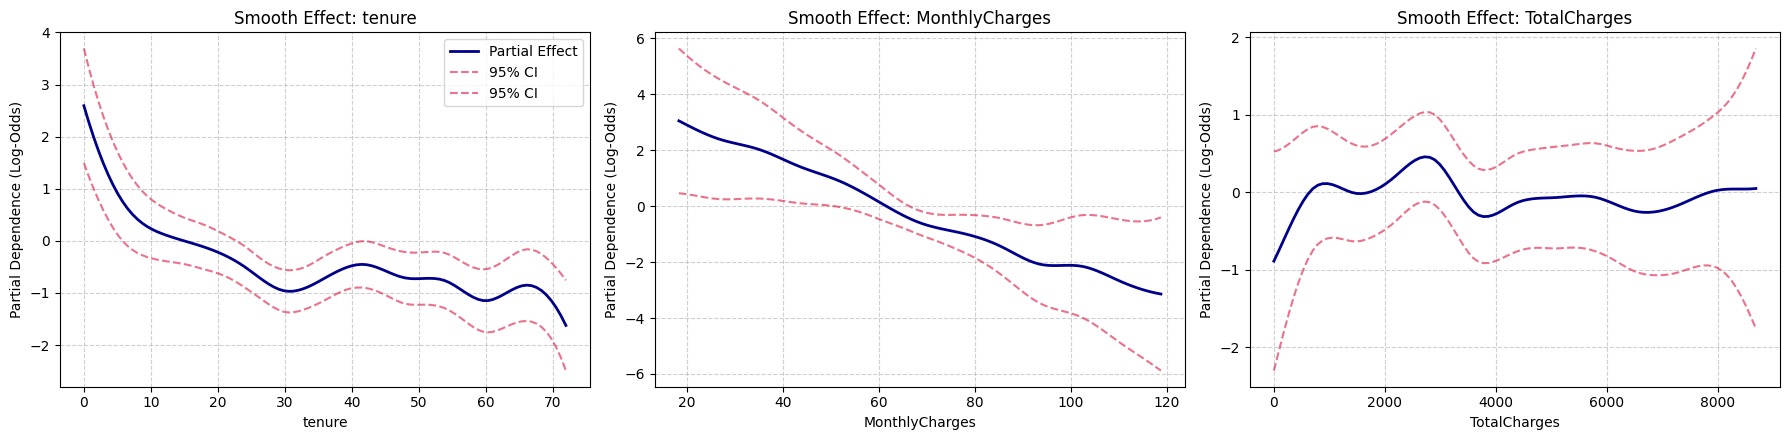

In [22]:
# Visualize Smooth Effects (Partial Dependence Plots)
smooth_indices = [0, 1, 2]
smooth_names = ["tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(18, 4.5))
for idx, (term_idx, name) in enumerate(zip(smooth_indices, smooth_names)):
    plt.subplot(1, 3, idx + 1)
    XX = gam.generate_X_grid(term=term_idx)
    pdep, confi = gam.partial_dependence(term=term_idx, X=XX, width=0.95)

    plt.plot(XX[:, term_idx], pdep, color="darkblue", lw=2, label="Partial Effect")
    plt.plot(XX[:, term_idx], confi, c="crimson", ls="--", alpha=0.6, label="95% CI")
    plt.title(f"Smooth Effect: {name}")
    plt.xlabel(name)
    plt.ylabel("Partial Dependence (Log-Odds)")
    plt.grid(True, linestyle="--", alpha=0.6)
    if idx == 0:
        plt.legend()

plt.tight_layout()
plt.show()

**tenure:** Customers are far more likely to leave in the first 10 months. Once they stick around past roughly two years (20–30 months), churn risk drops significantly and levels out.

**MonthlyCharges:** The partial effect steadily trends downward as the monthly bill increases, once tenure and cumulative spend are held constant in the model.

**TotalCharges:** Churn risk climbs slightly through early spend, hits a small peak near \$2,500, and stays mostly flat afterward. The confidence bands widen noticeably at the high end (past $8,000) due to fewer accounts in that bracket.

## 6. At least one limitation of using a GAM for churn

**Misses feature interactions:** GAMs assume features act independently and just adds them up ($\sum f_i(x_i)$). In real churn behavior, features can interact strongly. If we had wanted to include the interactions, we should have manually coded the interaction splines.